# Surrogate model sanity check — XGB vs MLP vs GNN

Loads the three aggregated final models under `outputs/models/` and scores them on a
random 300-row sample of `data/sets/routes_test.csv`, comparing predictions against
ground-truth `synthesizability`.

Run this notebook's kernel from an env with **both** xgboost and torch installed
(needed since all three backends are loaded in one session) — e.g.
`apptainer run --app notebook ... apptainer/training.sif` (see `apptainer/README.md`)
or a `.venv` built with `uv sync --extra training --extra notebooks`. Run from the
repo root so the relative paths below resolve.

In [27]:
import os
from pathlib import Path

# Jupyter's kernel cwd depends on how it was launched (notebook's own dir vs.
# the server's --notebook-dir); normalize to the repo root so the relative
# paths below always resolve.
if not Path("pyproject.toml").exists() and Path("../pyproject.toml").exists():
    os.chdir("..")
print("cwd:", Path.cwd())

cwd: /opt/repo


In [28]:
import numpy as np
from rdkit import Chem
import pandas as pd
import matplotlib.pyplot as plt

from protac_synth.chem_utils import compute_descriptors, compute_fingerprints, standardize_all
from protac_synth.models.config import ModelsConfig
from protac_synth.models.metrics import compute_all_metrics

cfg = ModelsConfig.load("config/models_config_routes.yaml")   # target/molecule_col/fp params these models were trained with
SAMPLE_N, SEED = 300, 42
cfg.target, cfg.molecule_col, cfg.features.fp_size, cfg.features.fp_radius

('synthesizability', 'smiles', 1024, 8)

## Load & sample the test set

300 molecules sampled from routes_test.csv
Synthesizability of SMILES is 0.5510792365529207 for modelcule: O=C1CCC(N2Cc3cc(NCCOCCOc4ccc(Oc5c(-c6ccc(Br)cc6)sc6cc(O)ccc56)cc4)ccc3C2=O)C(=O)N1


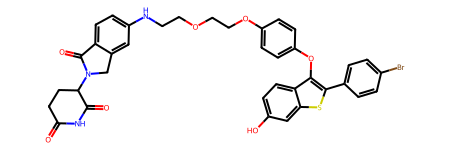

In [29]:
df = pd.read_csv("data/sets/routes_test.csv").sample(n=SAMPLE_N, random_state=SEED).reset_index(drop=True)
smiles = df[cfg.molecule_col].tolist()
y_true = df[cfg.target].to_numpy(dtype=float)
print(f"{len(smiles)} molecules sampled from routes_test.csv")
print(f"Synthesizability of SMILES is {y_true[0]} for modelcule: {smiles[0]}")
Chem.MolFromSmiles(smiles[0])  # sanity check: can we parse the first SMILES?

In [30]:
# Featurize once, shared across all three backends (GNN ignores these -- it builds its own graph input)
mols = standardize_all(smiles)
X_fp = compute_fingerprints(mols, cfg.features.fp_size, cfg.features.fp_radius)
X_desc = compute_descriptors(mols)

Computing descriptors: 100%|████████████████| 300/300 [00:08<00:00, 34.65mol/s]


## Load the aggregated models and predict

In [31]:
MODELS_DIR = Path("outputs/models")


def _latest_run(prefix: str) -> Path:
    matches = sorted(MODELS_DIR.glob(f"{prefix}_*"))
    if not matches:
        raise FileNotFoundError(f"no {prefix}_* run under {MODELS_DIR}")
    return matches[-1]   # most recent timestamped run, if more than one


def _load_backend(prefix: str):
    run_dir = _latest_run(prefix)
    base = run_dir / f"{run_dir.name}_final"
    if prefix == "xgb":
        from protac_synth.models.xgb.model import XGBoostRegressor as Backend
    elif prefix == "mlp":
        from protac_synth.models.mlp.model import TorchMLPRegressor as Backend
    else:
        from protac_synth.models.gnn.model import CheMeleonRegressor as Backend
    kwargs = {"device": "cpu"} if prefix == "gnn" else {}
    return Backend.load(str(base), **kwargs)


preds = {}
for prefix in ("xgb", "mlp", "gnn"):
    model = _load_backend(prefix)
    print(model)
    preds[prefix] = model.predict(smiles, X_fp=X_fp, X_desc=X_desc).reshape(-1)
    print(f"{prefix}: predicted {len(preds[prefix])} molecules")
    print(f"{prefix}: first 5 predictions: {preds[prefix][:5]}")

xgb: predicted 300 molecules
xgb: first 5 predictions: [0.5951823  0.60544956 0.5454647  0.6331988  0.609433  ]
mlp: predicted 300 molecules
mlp: first 5 predictions: [0.60227436 0.57418984 0.59268105 0.7037645  0.6404451 ]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/opt/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve 

gnn: predicted 300 molecules
gnn: first 5 predictions: [0.6128367 0.5122106 0.5009258 0.7127745 0.6440341]


In [26]:
s = "CC(=O)Nc1ccc(O)cc1" # Paracetamol
s = "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O" # Ibuprofen
s = "O=C(O)Cc1ccccc1Nc2c(Cl)cccc2Cl" # Diclofenac
s = "O=C(C)Oc1ccccc1C(=O)O" # Aspirin
s = "Cn1c(=O)c(C(=O)NNCCOCCOCC(=O)Nc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)nc2ccccc21"
model.predict([s], X_fp=X_fp, X_desc=X_desc).reshape(-1)[0]

Dropping last batch of size 1 to avoid issues with batch normalization     (dataset size = 1, batch_size = 64)


0.6252742

## A few predictions vs. ground truth

In [14]:
preview = pd.DataFrame({
    "smiles": [s[:40] + ("…" if len(s) > 40 else "") for s in smiles],
    "y_true": y_true,
    "xgb_pred": preds["xgb"],
    "mlp_pred": preds["mlp"],
    "gnn_pred": preds["gnn"],
})
preview.head(10)

,smiles,y_true,xgb_pred,mlp_pred,gnn_pred
0,O=C1CCC(N2Cc3cc(NCCOCCOc4ccc(Oc5c(-c6ccc…,0.551079,0.595182,0.602274,0.612837
1,CC(C)c1c(C(=O)Nc2ccccc2)c(-c2cccc(OCCCc3…,0.572418,0.605450,0.574190,0.512211
2,C#Cc1c(F)ccc2cc(O)cc(-c3c(F)cc4c(N5CC6CC…,0.597001,0.545465,0.592681,0.500926
3,CN[C@@H](C)C(=O)N[C@H](C(=O)N1CCC[C@H]1c…,0.709277,0.633199,0.703764,0.712775
4,CC/C(=C(\c1ccc(O)cc1)c1ccc(OCCN(C)C(=O)C…,0.747343,0.609433,0.640445,0.644034
5,Cc1cc(-c2ncnc3[nH]c(-c4ccc(N5CCN(C6CC(c7…,0.688803,0.659329,0.726086,0.720746
6,C[C@@H]1CN(c2ncc(Cl)c(Nc3ccc4c(c3F)CC(=O…,0.686680,0.651347,0.595538,0.601395
7,N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CC…,0.523804,0.562764,0.492989,0.552533
8,CCc1c(F)ccc2cc(O)cc(-c3ccc4c(N5CC6CCC(C5…,0.568272,0.590441,0.602522,0.343190
9,CC(C)[C@@H](C(=O)N1C[C@H](O)CC1C(=O)N[C@…,0.000000,0.000000,0.000000,0.110677


## How close are the predictions? (R², RMSE, MAE, Spearman ρ)

In [15]:
metrics = {
    label.upper(): compute_all_metrics(y_true, pred, threshold=cfg.hpo.classification_threshold)
    for label, pred in preds.items()
}
metrics_df = pd.DataFrame(metrics).T[["r2", "rmse", "mae", "spearman_rho", "clf_roc_auc", "n_samples"]]
metrics_df.round(4)

,r2,rmse,mae,spearman_rho,clf_roc_auc,n_samples
XGB,0.4671,0.1469,0.0828,0.6403,0.8218,300.0
MLP,0.4848,0.1444,0.0795,0.6370,0.8257,300.0
GNN,0.5157,0.1400,0.0857,0.6423,0.8405,300.0


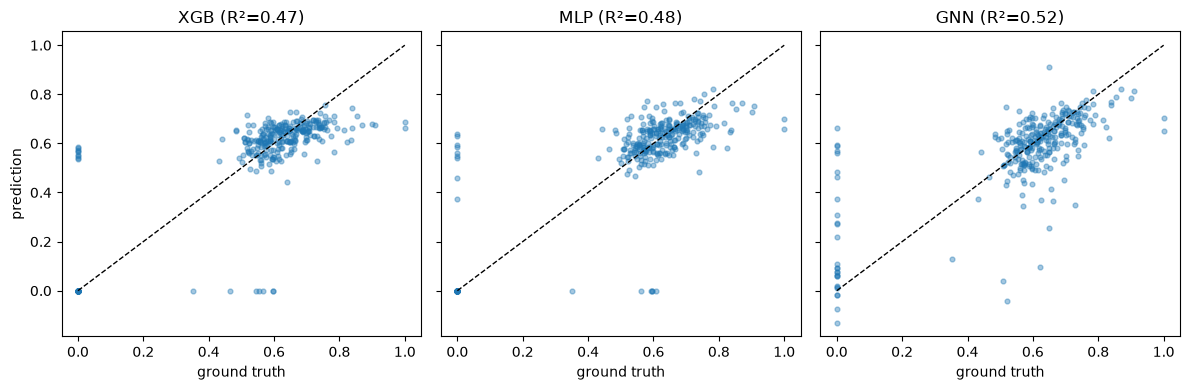

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for ax, label in zip(axes, preds):
    ax.scatter(y_true, preds[label], alpha=0.4, s=12)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(f"{label.upper()} (R²={metrics_df.loc[label.upper(), 'r2']:.2f})")
    ax.set_xlabel("ground truth")
axes[0].set_ylabel("prediction")
fig.tight_layout()